# Phase 1: Exploratory Data Analysis — Ames Housing

**Phase doc:** `docs/phases/phase-01-discovery-and-eda.md`  
**Dataset:** `ml/data/ames.csv` (1,460 rows, 81 columns)  
**Goal:** Resolve unknowns U-01 through U-10 and answer Q1–Q5 before Phase 2 begins.

---

## EDA Summary
*(Fill this in at the end of Phase 1 once all sections below are complete)*

| Decision | Answer |
|----------|--------|
| SalePrice log-transform? | |
| Outliers removed? | |
| Final feature count | |
| Required features | |
| Encoding strategy | |
| Baseline MAE target | |

---

**Checklist status:** Update `docs/phases/phase-01-discovery-and-eda.md` and `docs/context/assumptions-and-open-questions.md` as each section is completed.

---
## Section 1: Import Libraries and Load Dataset

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split

# Plot defaults
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
sns.set_theme(style="whitegrid")

# Load dataset — path is relative to this notebook's directory (ml/)
DATA_PATH = "data/ames.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\nSalePrice — min: ${df['SalePrice'].min():,.0f}  |  median: ${df['SalePrice'].median():,.0f}  |  max: ${df['SalePrice'].max():,.0f}")

Shape: (1460, 81)
Rows: 1,460  |  Columns: 81

SalePrice — min: $34,900  |  median: $163,000  |  max: $755,000


---
## Section 2: Initial Dataset Inspection

Separate numeric and categorical columns. Cross-reference against the Ames data dictionary before proceeding — column names in this dataset are often ambiguous without it.

Data dictionary reference: https://www.openml.org/d/42165 (or the PDF bundled with the original Kaggle dataset)

In [19]:
# Column names and dtypes overview
print("=== Column dtype summary ===")
print(df.dtypes.value_counts())
print()

# Separate by type
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Remove target and Id from feature lists
numeric_cols = [c for c in numeric_cols if c not in ("SalePrice", "Id")]
categorical_cols = [c for c in categorical_cols if c != "Id"]

print(f"Numeric features   : {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print()
print("Numeric   :", sorted(numeric_cols))
print()
print("Categorical:", sorted(categorical_cols))

=== Column dtype summary ===
str        43
int64      35
float64     3
Name: count, dtype: int64

Numeric features   : 36
Categorical features: 43

Numeric   : ['1stFlrSF', '2ndFlrSF', '3SsnPorch', 'BedroomAbvGr', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF', 'EnclosedPorch', 'Fireplaces', 'FullBath', 'GarageArea', 'GarageCars', 'GarageYrBlt', 'GrLivArea', 'HalfBath', 'KitchenAbvGr', 'LotArea', 'LotFrontage', 'LowQualFinSF', 'MSSubClass', 'MasVnrArea', 'MiscVal', 'MoSold', 'OpenPorchSF', 'OverallCond', 'OverallQual', 'PoolArea', 'ScreenPorch', 'TotRmsAbvGrd', 'TotalBsmtSF', 'WoodDeckSF', 'YearBuilt', 'YearRemodAdd', 'YrSold']

Categorical: ['Alley', 'BldgType', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual', 'CentralAir', 'Condition1', 'Condition2', 'Electrical', 'ExterCond', 'ExterQual', 'Exterior1st', 'Exterior2nd', 'Fence', 'FireplaceQu', 'Foundation', 'Functional', 'GarageCond', 'GarageFinish', 'GarageQual', 'GarageType', 'Heating'

/tmp/ipykernel_14391/1917716183.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [20]:
# Sample rows (excludes Id and SalePrice for readability)
display(df.drop(columns=["Id"]).head(5))

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## Section 3: Train / Test Split

> **ML Rule:** Split FIRST — before any analysis, correlation, or imputation statistics.  
> All analysis from this point on uses **training data only**.  
> The test set is not inspected again until final evaluation in Phase 2.

Split: 80% train / 20% test, `random_state=42`

In [21]:
df_features = df.drop(columns=["Id", "SalePrice"])
df_target = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    df_features, df_target, test_size=0.2, random_state=42
)

# Re-attach target to training frame for exploratory analysis
train = X_train.copy()
train["SalePrice"] = y_train.values

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print("All analysis below uses train only.")

Train: 1,168 rows  |  Test: 292 rows
All analysis below uses train only.


---
## Section 4: Missing Value Analysis

**Resolves:** U-02 (severity of missing values), U-07 (Ames-specific NA semantics), U-10 (imputation strategy)

Rule: Many Ames "NA" values are **not** data gaps — they mean "feature does not exist" (e.g., `PoolQC = NA` means no pool, `GarageType = NA` means no garage). These must be encoded as a distinct "None" category, not imputed with the mode.

In [22]:
# Missing value counts on training data only
missing = X_train.isnull().sum()
missing_pct = (missing / len(X_train) * 100).round(1)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("pct", ascending=False)

print(f"Columns with any missing values: {len(missing_df)}")
print()
print(missing_df.to_string())

Columns with any missing values: 19

              count   pct
PoolQC         1162  99.5
MiscFeature    1122  96.1
Alley          1094  93.7
Fence           935  80.1
MasVnrType      683  58.5
FireplaceQu     547  46.8
LotFrontage     217  18.6
GarageType       64   5.5
GarageYrBlt      64   5.5
GarageFinish     64   5.5
GarageQual       64   5.5
GarageCond       64   5.5
BsmtCond         28   2.4
BsmtFinType1     28   2.4
BsmtExposure     28   2.4
BsmtQual         28   2.4
BsmtFinType2     28   2.4
MasVnrArea        6   0.5
Electrical        1   0.1


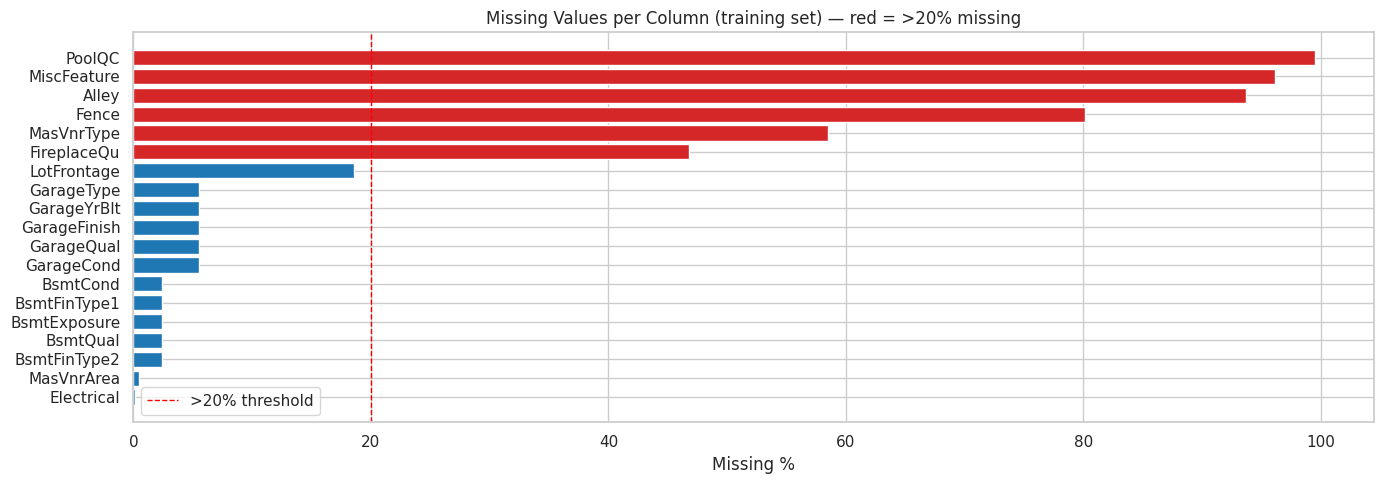


Columns with >20% missing: 6
             count   pct
PoolQC        1162  99.5
MiscFeature   1122  96.1
Alley         1094  93.7
Fence          935  80.1
MasVnrType     683  58.5
FireplaceQu    547  46.8


In [23]:
# Bar chart of missing % (top 30 only for readability)
top_missing = missing_df.head(30)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#d62728" if p > 20 else "#1f77b4" for p in top_missing["pct"]]
ax.barh(top_missing.index[::-1], top_missing["pct"][::-1], color=colors[::-1])
ax.axvline(20, color="red", linestyle="--", linewidth=1, label=">20% threshold")
ax.set_xlabel("Missing %")
ax.set_title("Missing Values per Column (training set) — red = >20% missing")
ax.legend()
plt.tight_layout()
plt.show()

# Columns above 20% threshold
high_missing = missing_df[missing_df["pct"] > 20]
print(f"\nColumns with >20% missing: {len(high_missing)}")
print(high_missing)

In [33]:
# ── Examples of actual missing value rows ─────────────────────────────────────

# Group A: NA = "feature doesn't exist on this property"
# Show value counts so you can see that NaN dominates — this is the signal
group_a = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu"]

print("=== Group A — NA means 'no feature on this property' ===\n")
for col in group_a:
    print(f"  {col} value counts (including NaN):")
    print(X_train[col].value_counts(dropna=False).to_string())
    print()

# Show a few actual rows so you can see what the raw data looks like
print("Sample rows where FireplaceQu is NaN (no fireplace) vs not NaN (has fireplace):")
no_fp = X_train[X_train["FireplaceQu"].isnull()][["FireplaceQu", "Fireplaces"]].head(4)
no_fp["SalePrice"] = y_train.loc[no_fp.index].values

has_fp = X_train[X_train["FireplaceQu"].notna()][["FireplaceQu", "Fireplaces"]].head(4)
has_fp["SalePrice"] = y_train.loc[has_fp.index].values

print("\nNo fireplace (FireplaceQu = NaN, Fireplaces = 0):")
display(no_fp)
print("Has fireplace (FireplaceQu has a grade):")
display(has_fp)

# ── Group B: true missing values ──────────────────────────────────────────────
print("\n=== Group B — True missing values (data gaps) ===\n")
group_b = ["LotFrontage", "GarageYrBlt", "Electrical"]

for col in group_b:
    n = X_train[col].isnull().sum()
    print(f"  {col}: {n} missing row(s)")
    null_rows = X_train[X_train[col].isnull()][[col]].head(5).copy()
    null_rows["SalePrice"] = y_train.loc[null_rows.index].values
    display(null_rows)
    print()

=== Group A — NA means 'no feature on this property' ===

  PoolQC value counts (including NaN):
PoolQC
NaN    1162
Fa        2
Ex        2
Gd        2

  MiscFeature value counts (including NaN):
MiscFeature
NaN     1122
Shed      41
Othr       2
Gar2       2
TenC       1

  Alley value counts (including NaN):
Alley
NaN     1094
Grvl      44
Pave      30

  Fence value counts (including NaN):
Fence
NaN      935
MnPrv    128
GdPrv     50
GdWo      46
MnWw       9

  FireplaceQu value counts (including NaN):
FireplaceQu
NaN    547
Gd     305
TA     252
Fa      27
Ex      21
Po      16

Sample rows where FireplaceQu is NaN (no fireplace) vs not NaN (has fireplace):

No fireplace (FireplaceQu = NaN, Fireplaces = 0):


,FireplaceQu,Fireplaces,SalePrice
254,NaN,0,145000
638,NaN,0,85000
303,NaN,0,149900
1385,NaN,0,125500


Has fireplace (FireplaceQu has a grade):


,FireplaceQu,Fireplaces,SalePrice
1066,TA,1,178000
799,TA,2,175000
380,Gd,1,127000
86,Gd,1,174000



=== Group B — True missing values (data gaps) ===

  LotFrontage: 217 missing row(s)


,LotFrontage,SalePrice
221,NaN,200000
113,NaN,217000
342,NaN,87500
31,NaN,149350
405,NaN,150000



  GarageYrBlt: 64 missing row(s)


,GarageYrBlt,SalePrice
638,NaN,85000
210,NaN,98000
48,NaN,113000
155,NaN,79000
1030,NaN,160000



  Electrical: 1 missing row(s)


,Electrical,SalePrice
1379,NaN,167500


### Missing Value Decisions (U-02, U-07, U-10)

Two fundamentally different situations — never confuse them:

**Group A — "NA = the feature doesn't exist on this property"**  
These are NOT missing data. The NA carries real information and must be preserved.  
Dropping the column or imputing the mode would destroy the signal.

| Column | Missing % | What NA means | Handling strategy |
|--------|-----------|--------------|-------------------|
| `PoolQC` | ~99% | No pool | Encode as `"None"` category — most properties have no pool |
| `MiscFeature` | ~96% | No misc feature | Create `HasMiscFeature` binary (1/0), or encode as `"None"` |
| `Alley` | ~93% | No alley access | Create `HasAlley` binary (1/0) — cleaner for LLM extraction |
| `Fence` | ~80% | No fence | Encode as `"None"` category |
| `FireplaceQu` | ~47% | No fireplace | Encode as `"None"` category — `"None"` vs `"Ex"` is a strong price signal |
| `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond` | ~5% | No garage | Encode as `"None"` category |
| `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` | ~2% | No basement | Encode as `"None"` category |
| `MasVnrType` | ~0.5% | No masonry veneer | Encode as `"None"` |
| `MasVnrArea` | ~0.5% | No masonry veneer → area is 0 | Fill with `0` |

> **Why not drop them?** These features affect the model and prediction directly. A property with `FireplaceQu = "None"` sells for less than one with `FireplaceQu = "Ex"`. Removing this information would hurt model accuracy.

---

**Group B — True missing values (data gaps, not "no feature")**  
These are actual unknowns. The value exists for the property but wasn't recorded.

| Column | Missing % | Type | Strategy | Rationale |
|--------|-----------|------|---------|-----------|
| `LotFrontage` | ~17% | numeric | Impute **median by Neighborhood** | Lot sizes cluster by neighborhood; more accurate than global median |
| `GarageYrBlt` | ~5% | numeric | Fill with `YearBuilt` | If garage year is unknown, assume it was built with the house |
| `Electrical` | 1 row | categorical | Impute **mode** (`SBrkr`) | One row — not worth dropping; overwhelmingly most common value |

> **Rule:** All imputation values (medians, modes) are computed on the **training set only** and stored inside a `sklearn.Pipeline`. They are never recomputed on test data.

---
## Section 5: Target Variable Analysis (SalePrice)

**Resolves:** U-03 (distribution shape), answers Q4 (log-transform decision)

Key checks:
- Is the distribution right-skewed? (expected for prices)
- Does log1p make it approximately normal?
- If transforming: predictions in Phase 2 must be converted back with `np.expm1()` before returning to the user

SalePrice skewness (raw)  : 1.743
SalePrice skewness (log1p): 0.125
(|skewness| < 0.5 is considered approximately normal)


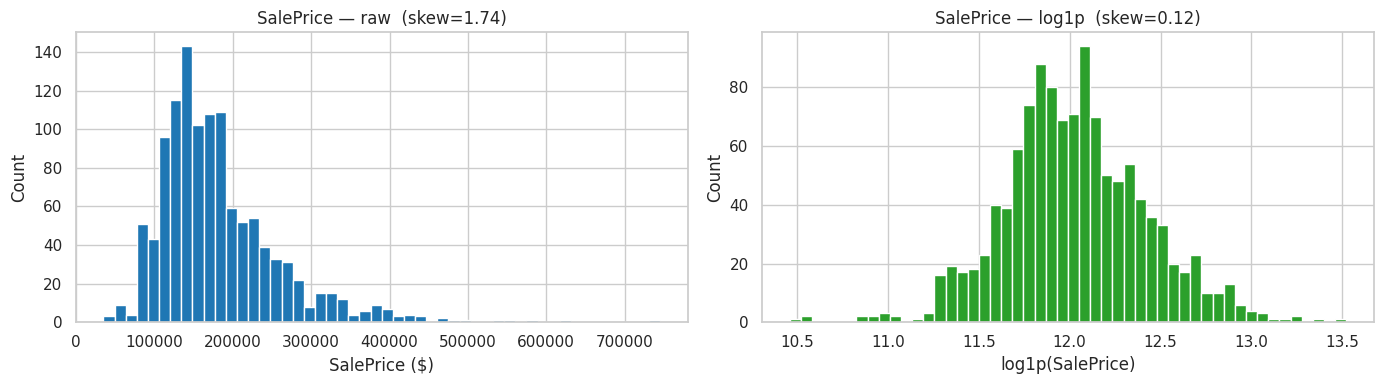

In [24]:
y_tr = y_train.copy()
skewness_raw = y_tr.skew()
skewness_log = np.log1p(y_tr).skew()

print(f"SalePrice skewness (raw)  : {skewness_raw:.3f}")
print(f"SalePrice skewness (log1p): {skewness_log:.3f}")
print(f"(|skewness| < 0.5 is considered approximately normal)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_tr, bins=50, edgecolor="white", color="#1f77b4")
axes[0].set_title(f"SalePrice — raw  (skew={skewness_raw:.2f})")
axes[0].set_xlabel("SalePrice ($)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(y_tr), bins=50, edgecolor="white", color="#2ca02c")
axes[1].set_title(f"SalePrice — log1p  (skew={skewness_log:.2f})")
axes[1].set_xlabel("log1p(SalePrice)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

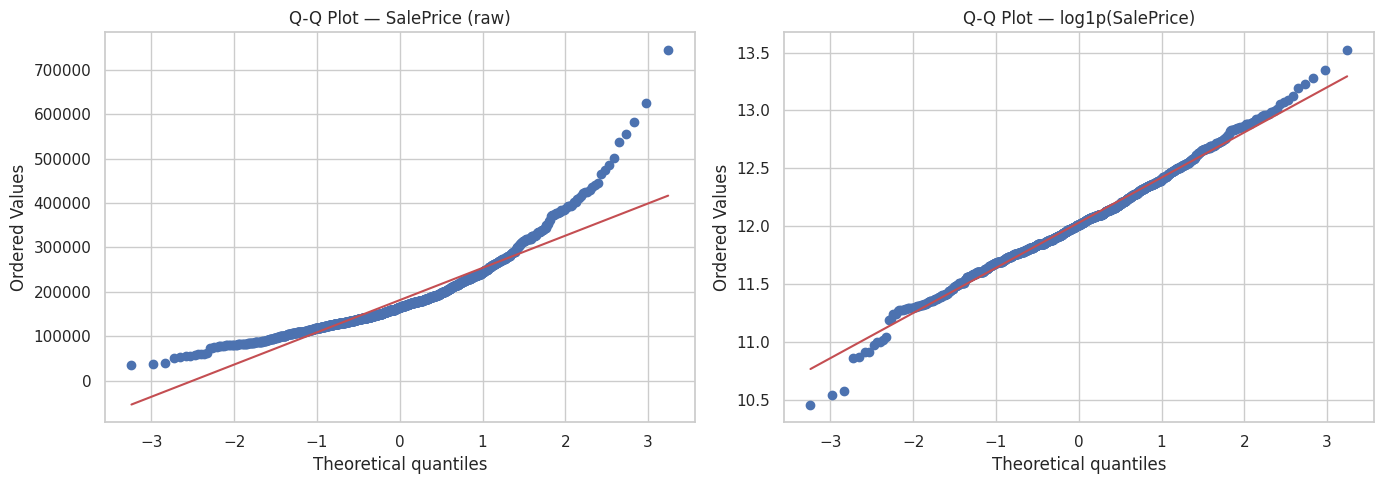

In [25]:
# Q-Q plots to assess normality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(y_tr, plot=axes[0])
axes[0].set_title("Q-Q Plot — SalePrice (raw)")

stats.probplot(np.log1p(y_tr), plot=axes[1])
axes[1].set_title("Q-Q Plot — log1p(SalePrice)")

plt.tight_layout()
plt.show()

### Decision — Log Transform (U-03, Q4)

- **Raw skewness:** 1.74
- **log1p skewness:** 0.12
- **Q-Q raw:** Yes — upper tail curves sharply away from the reference line, confirming a heavy right tail
- **Q-Q log1p:** Yes — line is nearly straight end-to-end, including both tails

**Decision:** Will `SalePrice` be log-transformed during training?
- [x] Yes — apply `np.log1p()` before training; convert predictions back with `np.expm1()`
- [ ] No — train on raw `SalePrice`

**Rationale:** Raw skewness of 1.74 is well above the 0.5 normality threshold; log1p reduces it to 0.12 (near-normal), which compresses the luxury-price tail and produces better-calibrated proportional errors across the full price range.

---
## Section 6: Feature Correlation and Importance

**Resolves:** U-01 (most predictive features), U-09 (near-duplicate features)

> All correlation computations use training data only.

Top 20 features by |Pearson correlation| with SalePrice (training set):
OverallQual     0.785555
GrLivArea       0.695652
GarageCars      0.640991
GarageArea      0.624139
TotalBsmtSF     0.597766
1stFlrSF        0.587883
FullBath        0.552546
TotRmsAbvGrd    0.520388
YearBuilt       0.516501
YearRemodAdd    0.508593
GarageYrBlt     0.480351
MasVnrArea      0.459123
Fireplaces      0.457549
BsmtFinSF1      0.359460
LotFrontage     0.330066
WoodDeckSF      0.329843
2ndFlrSF        0.314030
OpenPorchSF     0.299969
HalfBath        0.280481
LotArea         0.266204


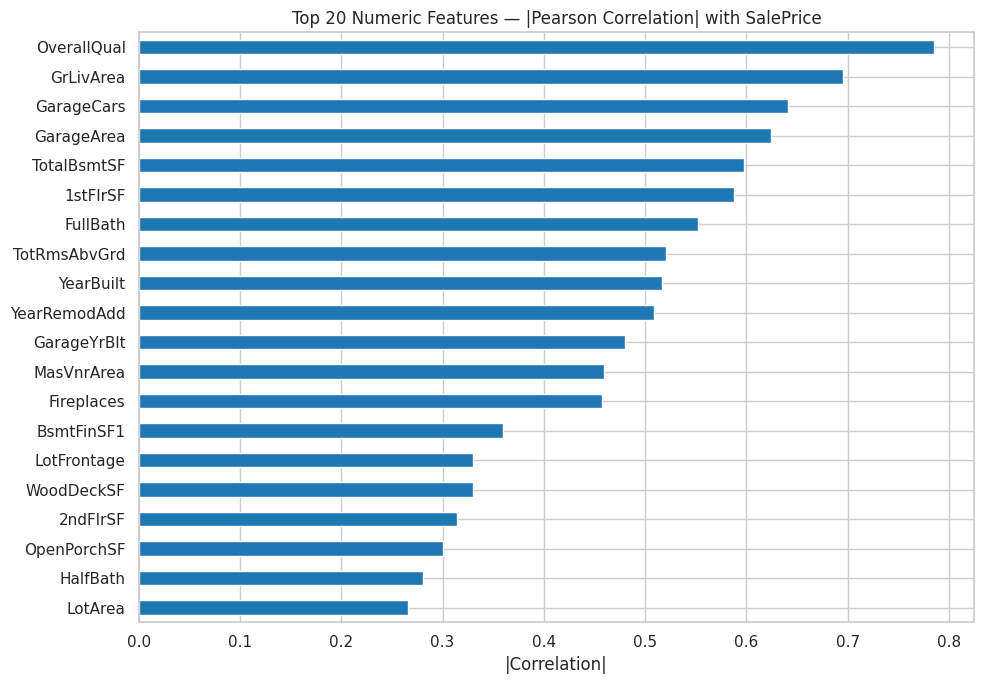

In [26]:
# Pearson correlation with SalePrice — numeric features only, training set
train_numeric = train[numeric_cols + ["SalePrice"]].copy()
corr_with_target = (
    train_numeric.corr()["SalePrice"]
    .drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
)

print("Top 20 features by |Pearson correlation| with SalePrice (training set):")
print(corr_with_target.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
corr_with_target.head(20).sort_values().plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title("Top 20 Numeric Features — |Pearson Correlation| with SalePrice")
ax.set_xlabel("|Correlation|")
plt.tight_layout()
plt.show()

In [27]:
# Near-duplicate / redundant feature check (U-09)
# Check suspected overlapping features
overlap_groups = {
    "Basement area": ["TotalBsmtSF", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF"],
    "Above-grade living": ["GrLivArea", "1stFlrSF", "2ndFlrSF", "LowQualFinSF"],
    "Garage": ["GarageArea", "GarageCars"],
    "Bathrooms": ["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"],
    "Porch/outdoor": ["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "WoodDeckSF"],
}

print("Correlation within suspected overlap groups (training set):\n")
for group_name, cols in overlap_groups.items():
    available = [c for c in cols if c in train_numeric.columns]
    if len(available) > 1:
        print(f"--- {group_name} ---")
        print(train_numeric[available].corr().round(2))
        print()

Correlation within suspected overlap groups (training set):

--- Basement area ---
             TotalBsmtSF  BsmtFinSF1  BsmtFinSF2  BsmtUnfSF
TotalBsmtSF         1.00        0.52        0.11       0.42
BsmtFinSF1          0.52        1.00       -0.04      -0.50
BsmtFinSF2          0.11       -0.04        1.00      -0.20
BsmtUnfSF           0.42       -0.50       -0.20       1.00

--- Above-grade living ---
              GrLivArea  1stFlrSF  2ndFlrSF  LowQualFinSF
GrLivArea          1.00      0.56      0.69          0.14
1stFlrSF           0.56      1.00     -0.21         -0.01
2ndFlrSF           0.69     -0.21      1.00          0.07
LowQualFinSF       0.14     -0.01      0.07          1.00

--- Garage ---
            GarageArea  GarageCars
GarageArea        1.00        0.88
GarageCars        0.88        1.00

--- Bathrooms ---
              FullBath  HalfBath  BsmtFullBath  BsmtHalfBath
FullBath          1.00      0.13         -0.07         -0.05
HalfBath          0.13      1.00     

Top 20 features by LightGBM importance (numeric only, training set):
GrLivArea       551
LotArea         498
TotalBsmtSF     453
1stFlrSF        445
GarageArea      425
BsmtFinSF1      367
OpenPorchSF     287
YearBuilt       270
MasVnrArea      267
BsmtUnfSF       264
LotFrontage     256
2ndFlrSF        232
GarageYrBlt     212
YearRemodAdd    192
TotRmsAbvGrd    172
MoSold          167
WoodDeckSF      150
OverallQual     137
YrSold          113
OverallCond     112


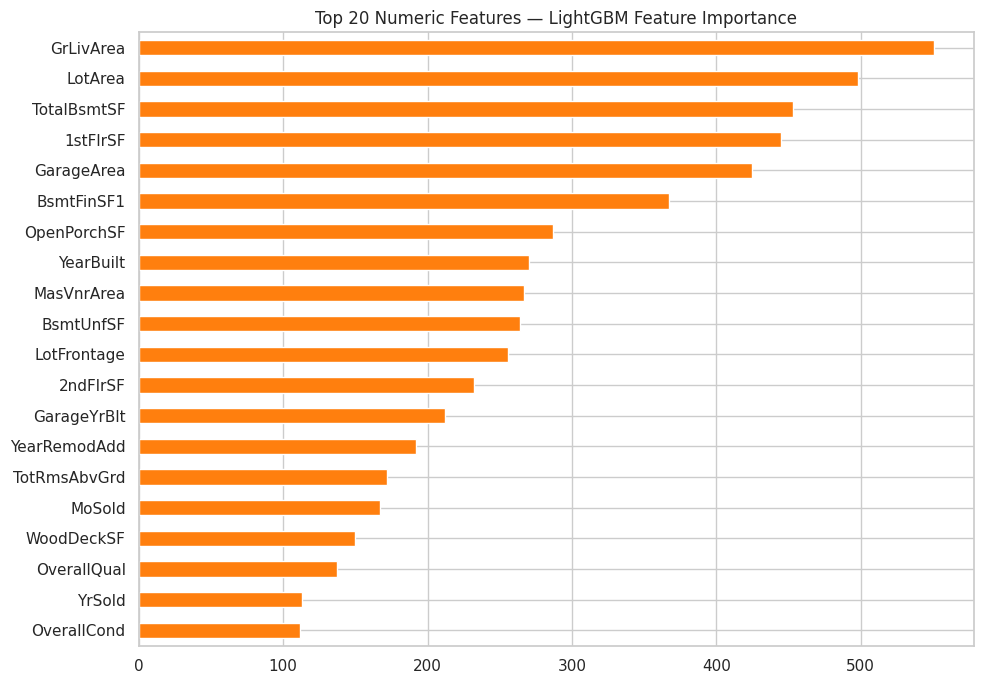

In [28]:
# Quick LightGBM feature importance — no tuning, just ranking signal
# Uses training data only; NaN columns are temporarily filled for this run
import lightgbm as lgb

X_tr_imp = X_train[numeric_cols].fillna(X_train[numeric_cols].median())
lgb_model = lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
lgb_model.fit(X_tr_imp, y_train)

importances = pd.Series(lgb_model.feature_importances_, index=numeric_cols)
importances = importances.sort_values(ascending=False)

print("Top 20 features by LightGBM importance (numeric only, training set):")
print(importances.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
importances.head(20).sort_values().plot(kind="barh", ax=ax, color="#ff7f0e")
ax.set_title("Top 20 Numeric Features — LightGBM Feature Importance")
plt.tight_layout()
plt.show()

### Observations — Correlation and Importance (U-01, U-09)

**Top features by Pearson correlation (|r| > 0.5, training set):**
`OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`, `FullBath`, `TotRmsAbvGrd`, `YearBuilt`

At a lower threshold (|r| > 0.4): also `GarageYrBlt`, `MasVnrArea`, `Fireplaces`

**Top features by LightGBM importance:**
Features confirmed by both Pearson and LightGBM (strongest candidates): `OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, `YearBuilt`, `FullBath` — both methods agree on these, which gives high confidence they are genuine predictors and not correlation artifacts.

**Near-duplicate features found and resolved:**

| Group | Features | Decision | Kept | Rationale |
|-------|----------|----------|------|-----------|
| Garage size | `GarageArea`, `GarageCars` | Keep one | `GarageCars` | Higher correlation; number of cars is more natural to describe in plain English |
| Above-grade living | `GrLivArea`, `1stFlrSF`, `TotRmsAbvGrd` | Keep one | `GrLivArea` | Sq ft is more precise than floor count or room count; LLM can extract it reliably |
| Basement | `TotalBsmtSF`, `BsmtFinSF1`, `BsmtUnfSF` | Keep aggregate | `TotalBsmtSF` | Captures total basement which is the price-relevant signal; sub-components add noise |

**Surprising or unexpected findings:**
The near-perfect overlap between the LightGBM and Pearson top lists suggests the dataset has a mostly linear structure — the dominant features have both strong linear and non-linear relationships with price. This is good news: it means a simple, well-encoded model has a realistic chance of performing well.

---
## Section 7: Outlier Analysis

**Resolves:** U-05 (outlier treatment decision)

The most important check: `GrLivArea` vs `SalePrice` reveals properties with very large above-grade living area but abnormally low sale price — likely partial sales or non-arms-length transactions.

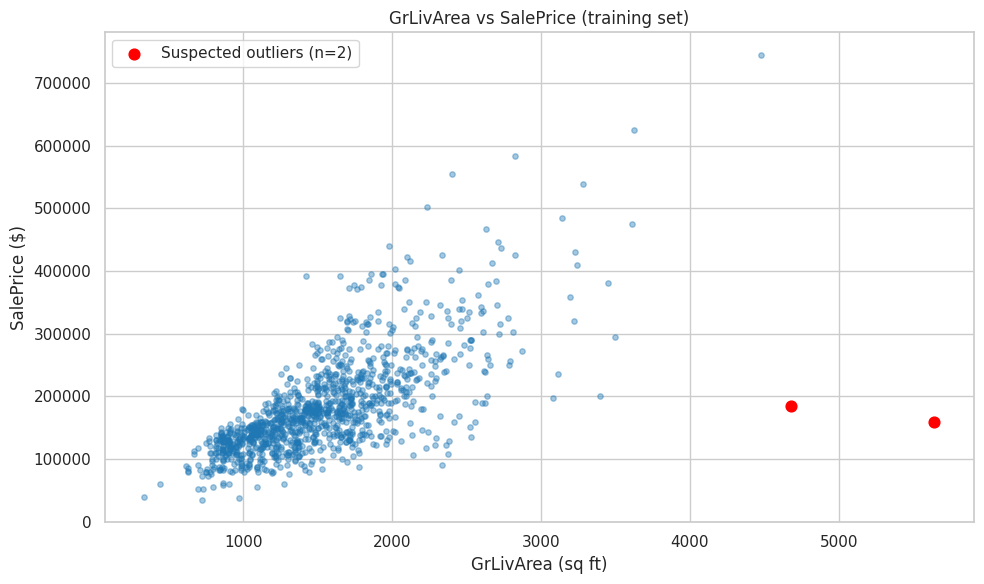

Suspected outliers (GrLivArea > 4000, SalePrice < $200k):
      GrLivArea  SalePrice Neighborhood SaleCondition
523        4676     184750      Edwards       Partial
1298       5642     160000      Edwards       Partial


In [29]:
# GrLivArea vs SalePrice — the primary outlier check (training set)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.4, s=15, color="#1f77b4")

# Highlight suspected outliers (large area, low price — Ames dataset known issue)
suspected = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 200_000)]
ax.scatter(suspected["GrLivArea"], suspected["SalePrice"],
           color="red", s=60, zorder=5, label=f"Suspected outliers (n={len(suspected)})")

ax.set_xlabel("GrLivArea (sq ft)")
ax.set_ylabel("SalePrice ($)")
ax.set_title("GrLivArea vs SalePrice (training set)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Suspected outliers (GrLivArea > 4000, SalePrice < $200k):")
print(suspected[["GrLivArea", "SalePrice", "Neighborhood", "SaleCondition"]].to_string())

In [30]:
# Check for erroneous values in key numeric columns (training set)
checks = {
    "YearBuilt": (train["YearBuilt"] < 1800) | (train["YearBuilt"] > 2010),
    "YearRemodAdd": (train["YearRemodAdd"] < 1800) | (train["YearRemodAdd"] > 2010),
    "GarageYrBlt": (train["GarageYrBlt"] < 1800) | (train["GarageYrBlt"] > 2010),
    "LotArea": train["LotArea"] <= 0,
    "GrLivArea": train["GrLivArea"] <= 0,
}

for col, mask in checks.items():
    n = mask.sum()
    if n > 0:
        print(f"⚠  {col}: {n} suspicious row(s)")
        print(train.loc[mask, [col, "SalePrice"]].to_string())
        print()
    else:
        print(f"   {col}: OK")

   YearBuilt: OK
   YearRemodAdd: OK
   GarageYrBlt: OK
   LotArea: OK
   GrLivArea: OK


### Decision — Outlier Treatment (U-05)

> Fill in after running the scatter plot above:

**What did you observe in the GrLivArea vs SalePrice plot?**  
*(e.g., "2 properties with >4,000 sq ft but <$200k — very unusual, likely non-arms-length sales")*

**Decision:**  
- [ ] Remove the suspected outliers (rows with GrLivArea > 4,000 AND SalePrice < $200k)  
- [ ] Keep all rows

**Rationale:** *(one sentence — why?)*

**Any erroneous values found in other columns?** *(yes/no — describe if yes)*

---
## Section 8: Categorical Feature Analysis

**Resolves:** U-04 (high-cardinality features), U-08 (Neighborhood price effect and schema requirement)

In [31]:
# Unique values per categorical feature (training set)
cat_uniq = (
    X_train[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
    .rename("unique_values")
)
cat_uniq_df = cat_uniq.reset_index()
cat_uniq_df.columns = ["feature", "unique_values"]
cat_uniq_df["high_cardinality"] = cat_uniq_df["unique_values"] > 20

print(f"Categorical features with >20 unique values (high cardinality):")
print(cat_uniq_df[cat_uniq_df["high_cardinality"]].to_string(index=False))
print()
print("All categorical features by unique value count:")
print(cat_uniq_df.to_string(index=False))

Categorical features with >20 unique values (high cardinality):
     feature  unique_values  high_cardinality
Neighborhood             25              True

All categorical features by unique value count:
      feature  unique_values  high_cardinality
 Neighborhood             25              True
  Exterior2nd             16             False
  Exterior1st             15             False
   Condition1              9             False
     SaleType              9             False
   HouseStyle              8             False
   Condition2              8             False
     RoofMatl              7             False
   Functional              7             False
 BsmtFinType2              6             False
    RoofStyle              6             False
 BsmtFinType1              6             False
SaleCondition              6             False
      Heating              6             False
   Foundation              6             False
   GarageType              6             Fa

TypeError: Axes.boxplot() got an unexpected keyword argument 'order'

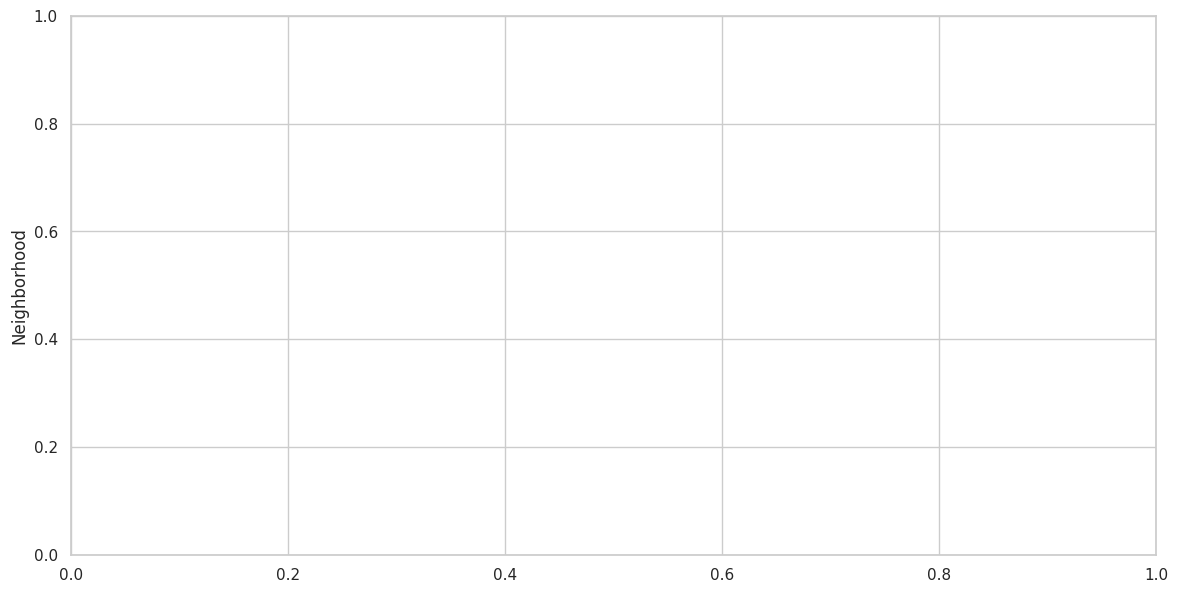

In [32]:
# SalePrice by Neighborhood — box plot (U-08)
neighborhood_order = (
    train.groupby("Neighborhood")["SalePrice"]
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(14, 7))
train.boxplot(
    column="SalePrice",
    by="Neighborhood",
    ax=ax,
    order=neighborhood_order,
    vert=False,
    flierprops=dict(marker=".", markersize=3),
)
ax.set_title("SalePrice by Neighborhood (sorted by median) — training set")
ax.set_xlabel("SalePrice ($)")
plt.suptitle("")
plt.tight_layout()
plt.show()

# Median SalePrice per neighborhood
print("Median SalePrice per Neighborhood (training set):")
print(train.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).to_string())

### Decisions — Categorical Features (U-04, U-08)

**High-cardinality features observed:**  
*(list which features have >20 unique values)*

| Feature | Unique Values | Decision | Encoding Strategy |
|---------|--------------|----------|-------------------|
| Neighborhood | ~25 | Keep / Drop | Target encoding / One-hot / Ordinal |
| *(others)* | | | |

**Neighborhood price effect:**  
Does the box plot show a strong price signal by neighborhood? *(yes/no — describe spread)*

**Decision — Is Neighborhood required in the schema?**  
- [ ] Yes — required (the price signal justifies asking the user)  
- [ ] No — optional (too variable or extractable from description)

**Observation on high-cardinality handling:**  
*(e.g., "Neighborhood has 25 values with clear price separation — will use target encoding fit on train only")*

---
## Section 9: Feature Selection for Schema

**Resolves:** U-06 (final feature shortlist), U-10 (imputation strategy per feature)  
**Answers:** Q1 (feature list), Q2 (baseline MAE target), Q3 (rare-value handling), Q5 (imputation strategy)

Selection criteria:
1. Feature appears in the top correlated OR top important lists
2. A homeowner or buyer can describe it in plain English
3. Not redundant with a stronger feature already in the list
4. The LLM can reliably extract it from a natural language description

In [ ]:
# Candidate feature summary — fill in after reviewing correlation and importance
# This cell generates the feature stats table for reference

CANDIDATE_FEATURES = [
    # (feature_name, type)
    # Fill in based on observations from Sections 6 and 8
    # Example entries — edit this list as you refine the shortlist:
    ("GrLivArea",    "numeric"),
    ("OverallQual",  "numeric"),
    ("TotalBsmtSF",  "numeric"),
    ("GarageCars",   "numeric"),
    ("YearBuilt",    "numeric"),
    ("Neighborhood", "categorical"),
    # Add more here...
]

print("Feature stats from training set:\n")
rows = []
for feat, ftype in CANDIDATE_FEATURES:
    if feat not in train.columns:
        rows.append({"feature": feat, "type": ftype, "note": "NOT IN DATASET"})
        continue
    col_data = train[feat]
    corr = abs(col_data.corr(train["SalePrice"])) if ftype == "numeric" else None
    missing_pct = col_data.isnull().mean() * 100
    if ftype == "numeric":
        rows.append({
            "feature": feat,
            "type": ftype,
            "corr_with_target": round(corr, 3) if corr else "-",
            "missing_%": round(missing_pct, 1),
            "min": col_data.min(),
            "max": col_data.max(),
        })
    else:
        rows.append({
            "feature": feat,
            "type": ftype,
            "corr_with_target": "-",
            "missing_%": round(missing_pct, 1),
            "unique_values": col_data.nunique(),
        })

display(pd.DataFrame(rows))

### Final Feature Schema — PropertyFeatures (Q1, Q2, Q3, Q5, U-06, U-10)

Fill in this table after completing all sections above.

| Feature | Ames Column | Type | Required? | Imputation Strategy | Valid Range / Values | Plain-English Prompt | Rationale |
|---------|------------|------|-----------|--------------------|--------------------|---------------------|-----------|
| Above-grade living area | `GrLivArea` | int | Yes | N/A (required) | 300–6000 sq ft | "What is the above-grade living area in square feet?" | Strongest numeric predictor |
| Overall quality | `OverallQual` | int (1–10) | Yes | N/A (required) | 1–10 | "Rate the overall material and finish quality from 1 (very poor) to 10 (excellent)" | 2nd strongest predictor |
| *(add rows)* | | | | | | | |

---

**Q1 — Final feature list:** *(paste feature names)*  
**Q2 — Baseline MAE target:** *(fill in after Phase 2 runs DummyRegressor)*  
**Q3 — Rare-value handling:** *(e.g., "Rare neighborhoods (<2% frequency) binned as 'Other'")*  
**Q5 — Imputation strategies:**  
- Numeric missing → *(median / 0 / drop)*  
- Categorical "NA = No feature" → *(encode as 'None')*  
- Categorical true missing → *(mode)*

---
## Phase 1 Exit Checklist

Before marking Phase 1 complete, confirm all of the following:

- [ ] Notebook runs end-to-end without errors  
- [ ] SalePrice log-transform decision is documented with supporting plots (Section 5)  
- [ ] Outlier treatment decision is documented with supporting plots (Section 7)  
- [ ] Every candidate schema feature has a documented imputation strategy (Section 9)  
- [ ] Feature shortlist (10–20 features) is written in the table above  
- [ ] Required vs. optional classification exists for every feature  
- [ ] U-01 through U-10 are checked off in `docs/context/assumptions-and-open-questions.md`  
- [ ] Q1–Q5 are answered in the table above  
- [ ] EDA Summary table at the top of this notebook is filled in  
- [ ] `docs/phases/phase-01-discovery-and-eda.md` Key Decisions section is filled in